In [155]:
import os
from dotenv import load_dotenv
load_dotenv()

True

In [156]:
SERPAPI_KEY = os.getenv("SERPAPI_KEY")
YOUTUBE_API_KEY = os.getenv("YOUTUBE_API_KEY")

In [ ]:
!pip install requests beautifulsoup4 pandas matplotlib



[notice] A new release of pip is available: 25.1.1 -> 25.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [91]:
queries = [
    "best smart fan in India",
    "BLDC ceiling fan review",
    "smart ceiling fans 2025",
    "BLDC fan with remote control",
    "energy saving ceiling fans",
    "top smart fans India",
    "smart fan comparison India",
    "remote-controlled ceiling fan",
    "BLDC vs normal fan",
    "popular ceiling fans India"
]


### IMPORTING GOOGLE DATA

In [92]:
def search_google_multi(queries, num_results=30):
    all_results = []
    for query in queries:
        url = "https://serpapi.com/search"
        params = {
            "engine": "google",
            "q": query,
            "api_key": SERPAPI_KEY,
            "num": num_results
        }
        response = requests.get(url, params=params)
        data = response.json()
        for item in data.get("organic_results", []):
            all_results.append({
                "platform": "Google",
                "title": item.get("title", ""),
                "snippet": item.get("snippet", ""),
                "link": item.get("link", ""),
                "query": query
            })
    return all_results


### IMPORTING YOUTUBE DATA

In [93]:
def search_youtube_multi(queries, max_results=30):
    all_results = []
    for query in queries:
        url = "https://www.googleapis.com/youtube/v3/search"
        params = {
            "part": "snippet",
            "q": query,
            "maxResults": max_results,
            "key": YOUTUBE_API_KEY,
            "type": "video"
        }
        response = requests.get(url, params=params)
        data = response.json()
        for item in data.get("items", []):
            snippet = item["snippet"]
            all_results.append({
                "platform": "YouTube",
                "title": snippet.get("title", ""),
                "snippet": snippet.get("description", ""),
                "link": f"https://www.youtube.com/watch?v={item['id']['videoId']}",
                "query": query
            })
    return all_results


#### COMBINING BOTH DATA

In [95]:
def get_combined_results(queries):
    google_data = search_google_multi(queries)
    youtube_data = search_youtube_multi(queries)
    
    combined = google_data + youtube_data
    print(f"Total combined results: {len(combined)}")
    return combined


### VISUALIZING THE COMBINED OUTPUT

In [96]:
results = get_combined_results(queries)

for r in results:
    print(f"[{r['platform']}] Query: '{r['query']}'\nTitle: {r['title']}\nSnippet: {r['snippet']}\nLink: {r['link']}\n---\n")

Total combined results: 574
[Google] Query: 'best smart fan in India'
Title: Buy Smart Fans Online At Amazing Prices Online In India
Snippet: Atomberg smart fans offer a blend of cutting-edge technology, energy efficiency, and sleek designs, making them the perfect choice for modern homes. Here's why ...
Link: https://atomberg.com/atomberg-ceiling-fans/smart-fans?srsltid=AfmBOopBibM7mE-xu0PFGuID_Qs06YixyVrRLJOzpbeyDygWL4Sv_yny
---

[Google] Query: 'best smart fan in India'
Title: Buy Smart Ceiling Fans at Best Prices in India
Snippet: Crompton's ActivBLDC fans are a smart choice for cutting electricity bills by up to 60%. They achieve this through two key features.
Link: https://www.crompton.co.in/collections/ceiling-fans/smart-fans
---

[Google] Query: 'best smart fan in India'
Title: Smart Fan
Snippet: Orient Electric 1200 mm Aerosense| Smart fan with IoT & Remote| BLDC fan with underlight| Save up to 50% on electricity bills| BEE 5-star rated| 5-year warranty ...
Link: https://www.a

### CHECKING FOR DUPLICATES

In [97]:
import pandas as pd

df = pd.DataFrame(results)


In [98]:
duplicate_titles = df[df.duplicated(subset='title')]
print("Duplicate Titles:")
print(duplicate_titles[['platform', 'title']])

Duplicate Titles:
    platform  \
28    Google   
44    Google   
51    Google   
54    Google   
66    Google   
..       ...   
563  YouTube   
564  YouTube   
565  YouTube   
566  YouTube   
567  YouTube   

                                                                                                title  
28                                                                 Best Ceiling Fans 2025 | BLDC Fans  
44                                       Best BLDC Smart Fan to Buy in India 2025 | Atomberg Aris ...  
51                                                                              Pls suggest BLDC Fan?  
54                                         Buy Premium BLDC Ceiling Fans At Best Prices Online In ...  
66                                                                                 Smart Ceiling Fans  
..                                                                                                ...  
563               Best BLDC Ceiling Fan In 2025⚡Top 3 BLDC Fa

In [99]:
duplicate_links = df[df.duplicated(subset='link')]
print("Duplicate Links:")
print(duplicate_links[['platform', 'link']])

Duplicate Links:
    platform  \
28    Google   
51    Google   
83    Google   
137   Google   
138   Google   
..       ...   
563  YouTube   
564  YouTube   
565  YouTube   
566  YouTube   
567  YouTube   

                                                                          link  
28                                 https://www.youtube.com/watch?v=NDKD-B_i3mg  
51                       https://techenclave.com/t/pls-suggest-bldc-fan/268530  
83   https://www.amazon.com/Iliving-ILG8CF52B-Ceiling-inch-Black/dp/B088W1VMWG  
137             https://www.crompton.co.in/collections/ceiling-fans/smart-fans  
138                                https://www.youtube.com/watch?v=NDKD-B_i3mg  
..                                                                         ...  
563                                https://www.youtube.com/watch?v=NdLwS2C5JAo  
564                                https://www.youtube.com/watch?v=rmVHbm9_RIE  
565                                https://www.youtube.com/wa

In [100]:
df = df.drop_duplicates(subset='link', keep='last').reset_index(drop=True)

In [101]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 402 entries, 0 to 401
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   platform  402 non-null    object
 1   title     402 non-null    object
 2   snippet   402 non-null    object
 3   link      402 non-null    object
 4   query     402 non-null    object
dtypes: object(5)
memory usage: 15.8+ KB
None


### DUPLICATE LINKS ARE REMOVED FOR UNIQUE DATA

### CREATING VECTOR DATABASE

In [9]:
pip install pandas sentence-transformers chromadb

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.1.1 -> 25.2
[notice] To update, run: python.exe -m pip install --upgrade pip


### CREATION OF VECTOR DB BY CONVERTING TO DATA FRAME

In [150]:
print(f"Scraped data size: {len(df)} rows")

Scraped data size: 160 rows


In [108]:
from sentence_transformers import SentenceTransformer
import faiss
import numpy as np

### CREATING EMBEDDINGS

In [110]:
from sentence_transformers import SentenceTransformer
df['content'] = df['title'] + " - " + df['snippet']

model = SentenceTransformer("all-MiniLM-L6-v2")
embeddings = model.encode(df['content'].tolist(), show_progress_bar=True)

Batches: 100%|██████████| 13/13 [00:15<00:00,  1.17s/it]


In [111]:
dimension = embeddings.shape[1]
index = faiss.IndexFlatL2(dimension)
index.add(np.array(embeddings))

In [112]:
faiss.write_index(index, "fan_sov_index.faiss")

In [113]:
print(df.columns)

Index(['platform', 'title', 'snippet', 'link', 'query', 'content'], dtype='object')


In [115]:
import pandas as pd

print(df.head())


  platform                                                       title  \
0   Google     Buy Smart Fans Online At Amazing Prices Online In India   
1   Google                          Best 5 Smart Ceiling Fans in India   
2   Google                 Buy Smart Ceiling Fans Online at Best Price   
3   Google  Buy Premium BLDC Ceiling Fans At Best Prices Online In ...   
4   Google                        Buy Smart Fans Online at Best Prices   

                                                                                                                                                                    snippet  \
0       Atomberg smart fans offer a blend of cutting-edge technology, energy efficiency, and sleek designs, making them the perfect choice for modern homes. Here's why ...   
1  Best 5 Smart Ceiling Fans in India · 1 · Atomberg Renesa · 2 · Orient Electric Aeroslim · 3 · Orient Electric Smart Premium Aeroslim Ceiling Fan · 4 · Havells Carnesia.   
2     AEON VC Smart BLDC Pro C

#### SHARE OF VOIVE (SOV)

In [133]:
brand_list = [
    "Atomberg", "Orient", "Crompton", "Havells", "Usha", "Luminous", "Bajaj", 
    "Khaitan", "V-Guard", "Syska", "Polycab", "Philips", "Surya", "Eveready",
    "Anchor", "RR Kabel", "Standard", "GM", "Goldmedal", "Halonix", "Superfan", "Philips"]


In [134]:
df['content'] = df['title'].fillna('') + ' ' + df['snippet'].fillna('')
df['content'] = df['content'].str.lower()


In [135]:
import pandas as pd

rows = []
platforms = df['platform'].unique()

for platform in platforms:
    df_platform = df[df['platform'] == platform]
    total_docs = len(df_platform)
    for brand in brand_list:
        brand_lower = brand.lower()
        mentions = df_platform['content'].str.contains(brand_lower).sum()
        sov = round((mentions / total_docs) * 100, 2) if total_docs else 0
        rows.append({
            'platform': platform,
            'brand': brand,
            'mentions': mentions,
            'total_docs': total_docs,
            'SOV (%)': sov
        })

sov_df = pd.DataFrame(rows)


In [136]:
sov_df = sov_df.sort_values(by=['platform', 'SOV (%)'], ascending=[True, False])


In [138]:
print(sov_df)

   platform      brand  mentions  total_docs  SOV (%)
0    Google   Atomberg        35         239    14.64
1    Google     Orient        23         239     9.62
3    Google    Havells        19         239     7.95
2    Google   Crompton        17         239     7.11
4    Google       Usha        11         239     4.60
6    Google      Bajaj         9         239     3.77
20   Google   Superfan         7         239     2.93
16   Google   Standard         5         239     2.09
8    Google    V-Guard         3         239     1.26
5    Google   Luminous         2         239     0.84
15   Google   RR Kabel         2         239     0.84
17   Google         GM         1         239     0.42
7    Google    Khaitan         0         239     0.00
9    Google      Syska         0         239     0.00
10   Google    Polycab         0         239     0.00
11   Google    Philips         0         239     0.00
12   Google      Surya         0         239     0.00
13   Google   Eveready      

#### PLOTTING GRAPH FOR SOV RESULTS

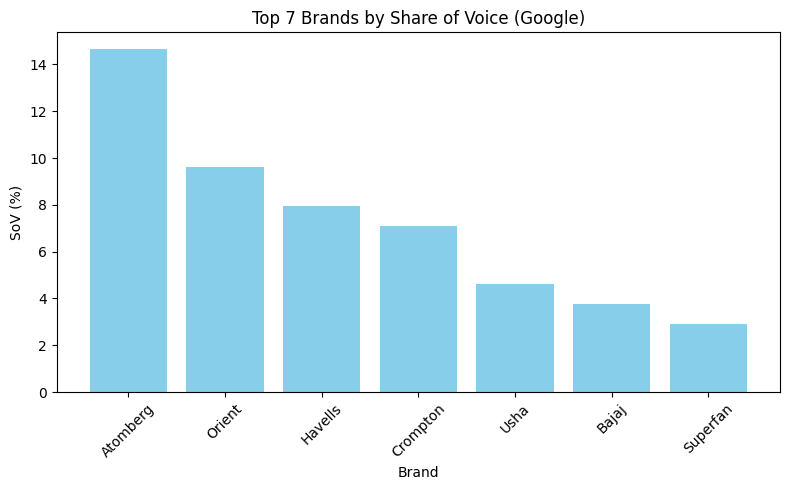

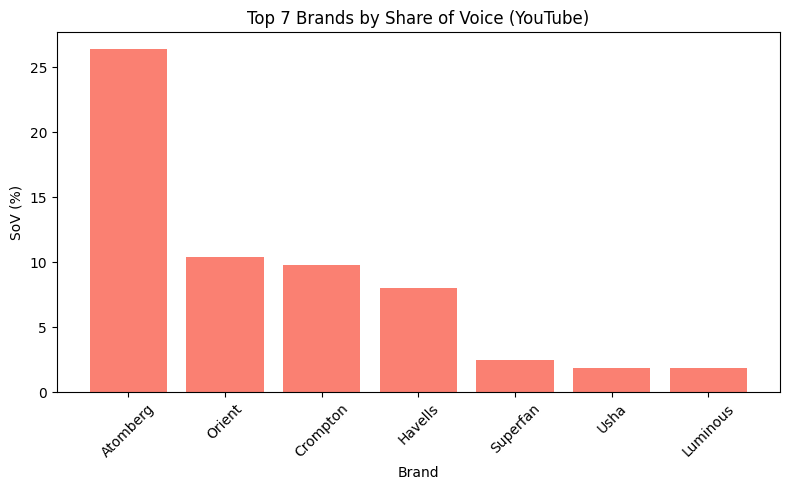

In [148]:
import pandas as pd
import matplotlib.pyplot as plt

# Filter top 7 brands for each platform
top7_google = sov_df[sov_df['platform'] == 'Google'].sort_values(by='SOV (%)', ascending=False).head(7)
top7_youtube = sov_df[sov_df['platform'] == 'YouTube'].sort_values(by='SOV (%)', ascending=False).head(7)

# Plot for Google
plt.figure(figsize=(8, 5))
plt.bar(top7_google['brand'], top7_google['SOV (%)'], color='skyblue')
plt.title('Top 7 Brands by Share of Voice (Google)')
plt.xlabel('Brand')
plt.ylabel('SoV (%)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Plot for YouTube
plt.figure(figsize=(8, 5))
plt.bar(top7_youtube['brand'], top7_youtube['SOV (%)'], color='salmon')
plt.title('Top 7 Brands by Share of Voice (YouTube)')
plt.xlabel('Brand')
plt.ylabel('SoV (%)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


### SENTIMENT ANALYSIS

In [139]:
df['content'] = df['title'].astype(str) + " - " + df['snippet'].astype(str)

In [140]:
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

analyzer = SentimentIntensityAnalyzer()

# Get sentiment score
df['sentiment_score'] = df['content'].apply(lambda x: analyzer.polarity_scores(x)['compound'])

# Categorize sentiment
df['sentiment'] = df['sentiment_score'].apply(
    lambda score: 'positive' if score >= 0.05 else ('negative' if score <= -0.05 else 'neutral')
)

In [141]:
print(df['sentiment'].value_counts())

sentiment
positive    390
neutral       8
negative      4
Name: count, dtype: int64


#### SHARE OF POSITIVE VOICE (SOPV)

SoPV (%)=( 
total mentions/positive mention)×100

In [143]:
df['brand'] = df['content'].apply(lambda x: next((b for b in brand_list if b.lower() in x.lower()), None))
df = df[df['brand'].notna()]


grouped = df.groupby(['platform', 'brand', 'sentiment']).size().unstack(fill_value=0).reset_index()

grouped['total_mentions'] = grouped[['positive', 'neutral', 'negative']].sum(axis=1)

grouped['SoPV (%)'] = (grouped['positive'] / grouped['total_mentions']) * 100

sopv_table = grouped[['platform', 'brand', 'positive', 'total_mentions', 'SoPV (%)']].sort_values(by='SoPV (%)', ascending=False)

print(sopv_table.to_string(index=False))


platform    brand  positive  total_mentions   SoPV (%)
  Google Atomberg        35              35 100.000000
  Google    Bajaj         2               2 100.000000
  Google Crompton         6               6 100.000000
  Google       GM         1               1 100.000000
  Google  Havells         6               6 100.000000
  Google   Orient        10              10 100.000000
  Google RR Kabel         1               1 100.000000
  Google Standard         5               5 100.000000
  Google Superfan         5               5 100.000000
  Google     Usha         2               2 100.000000
  Google  V-Guard         1               1 100.000000
 YouTube    Bajaj         1               1 100.000000
 YouTube  Havells        11              11 100.000000
 YouTube     Usha         2               2 100.000000
 YouTube Luminous         2               2 100.000000
 YouTube   Orient        14              14 100.000000
 YouTube  Polycab         2               2 100.000000
 YouTube  

In [145]:
from keybert import KeyBERT

kw_model = KeyBERT()

positive_keywords = kw_model.extract_keywords(
    ' '.join(df[df['sentiment'] == 'positive']['content'].tolist()), 
    top_n=30, stop_words='english'
)

neutral_keywords = kw_model.extract_keywords(
    ' '.join(df[df['sentiment'] == 'neutral']['content'].tolist()), 
    top_n=10, stop_words='english'
)

negative_keywords = kw_model.extract_keywords(
    ' '.join(df[df['sentiment'] == 'negative']['content'].tolist()), 
    top_n=10, stop_words='english'
)


In [146]:
print("\n Top Positive Keywords:")
for kw in positive_keywords:
    print(f"{kw[0]} (Score: {kw[1]:.2f})")

print("\n Top Neutral Keywords:")
for kw in neutral_keywords:
    print(f"{kw[0]} (Score: {kw[1]:.2f})")

print("\n Top Negative Keywords:")
for kw in negative_keywords:
    print(f"{kw[0]} (Score: {kw[1]:.2f})")



 Top Positive Keywords:
ceilingfan (Score: 0.38)
bldcfans (Score: 0.37)
bldcfan (Score: 0.34)
ledfan (Score: 0.33)
bldcfanunder3000 (Score: 0.32)
bldcfanvsnormalfan (Score: 0.30)
atombergfan (Score: 0.29)
starlight (Score: 0.28)
cooling (Score: 0.28)
india (Score: 0.27)
smartfan (Score: 0.26)
fandeal (Score: 0.26)
atombergbldc (Score: 0.26)
fan (Score: 0.26)
luminous (Score: 0.24)
delhi (Score: 0.24)
bldc (Score: 0.24)
indian (Score: 0.24)
rs (Score: 0.23)
rating (Score: 0.23)
flipkart (Score: 0.22)
smartgadgets (Score: 0.22)
bldcfancomparison (Score: 0.21)
brands (Score: 0.21)
smartest (Score: 0.21)
reviews (Score: 0.21)
suggest (Score: 0.20)
28w (Score: 0.20)
orientceilingfan (Score: 0.20)
bestceilingfan (Score: 0.20)

 Top Neutral Keywords:
1400mm (Score: 0.61)
atomberg (Score: 0.53)
renesa (Score: 0.35)
3850 (Score: 0.29)
website (Score: 0.21)
mrp (Score: 0.20)

 Top Negative Keywords:
exhaust (Score: 0.50)
bldcfan (Score: 0.42)
atomberg (Score: 0.39)
fan (Score: 0.36)
bldc (Score

### SENTIMENT ANALYSIS SCORE

In [147]:
import pandas as pd

df_keywords = pd.DataFrame({
    'Sentiment': ['Positive'] * len(positive_keywords) + ['Neutral'] * len(neutral_keywords) + ['Negative'] * len(negative_keywords),
    'Keyword': [kw[0] for kw in positive_keywords + neutral_keywords + negative_keywords],
    'Score': [kw[1] for kw in positive_keywords + neutral_keywords + negative_keywords]
})

display(df_keywords)


,Sentiment,Keyword,Score
0,Positive,ceilingfan,0.3831
1,Positive,bldcfans,0.3731
2,Positive,bldcfan,0.3362
3,Positive,ledfan,0.3287
4,Positive,bldcfanunder3000,0.3156
5,Positive,bldcfanvsnormalfan,0.2983
6,Positive,atombergfan,0.2928
7,Positive,starlight,0.2811
8,Positive,cooling,0.2769
9,Positive,india,0.2733


#### PLOTTING SENTIMENT ANALYSIS GRAPH

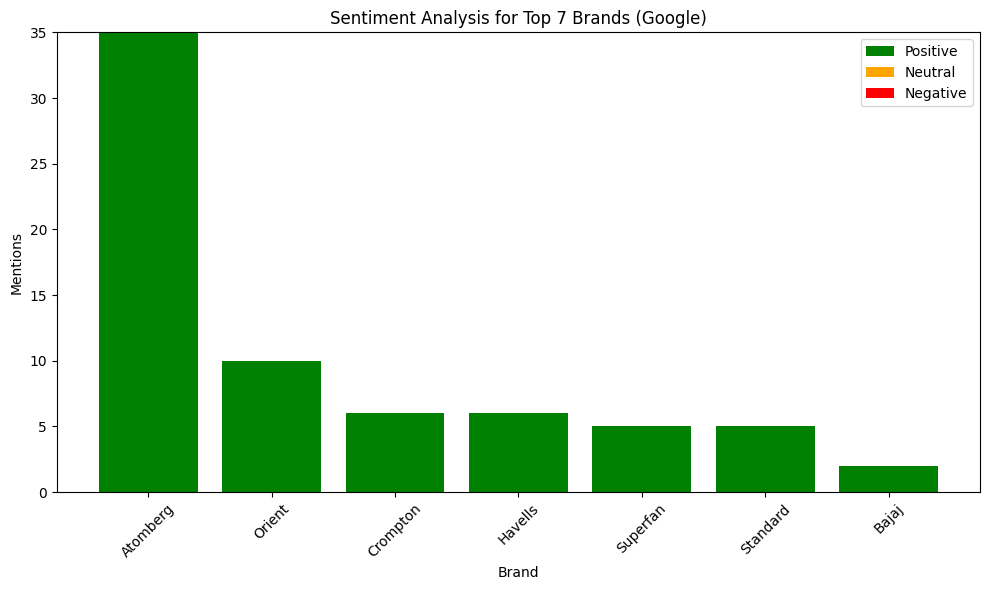

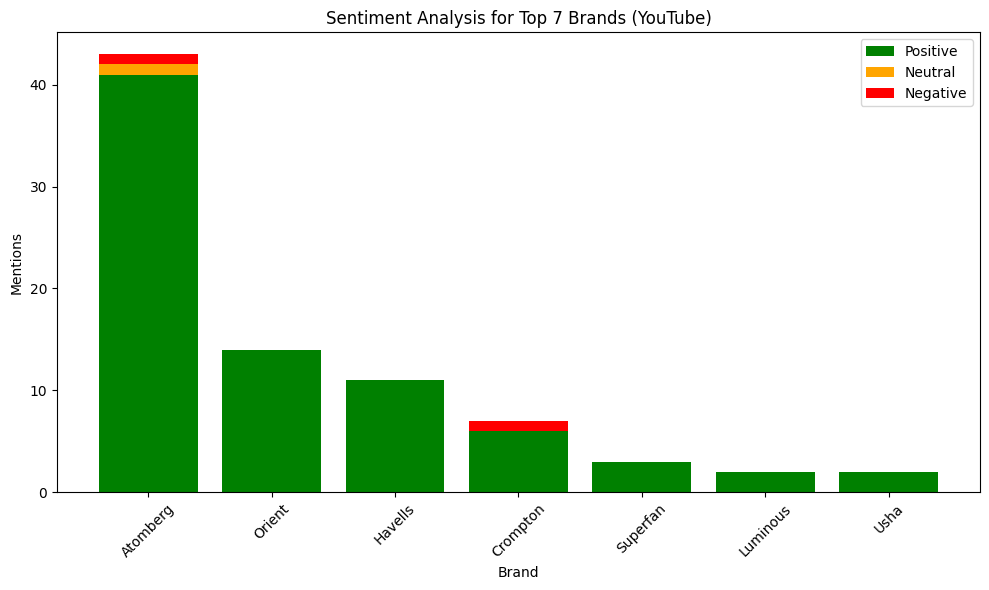

In [149]:
import pandas as pd
import matplotlib.pyplot as plt

# STEP 1: Group your data by platform, brand, and sentiment
# Assumption: df has columns ['platform', 'brand', 'sentiment']
sentiment_counts = df.groupby(['platform', 'brand', 'sentiment']).size().reset_index(name='count')

# STEP 2: Pivot to get separate columns for sentiments
sentiment_pivot = sentiment_counts.pivot_table(index=['platform', 'brand'], 
                                                columns='sentiment', 
                                                values='count', 
                                                fill_value=0).reset_index()

# Optional: Rename sentiment columns if needed
sentiment_pivot.columns.name = None
sentiment_pivot = sentiment_pivot.rename(columns={
    'positive': 'Positive', 
    'neutral': 'Neutral', 
    'negative': 'Negative'
})

# STEP 3: Get total mentions and top 7 brands per platform
sentiment_pivot['Total'] = sentiment_pivot[['Positive', 'Neutral', 'Negative']].sum(axis=1)

top7_google = sentiment_pivot[sentiment_pivot['platform'] == 'Google'].sort_values(by='Total', ascending=False).head(7)
top7_youtube = sentiment_pivot[sentiment_pivot['platform'] == 'YouTube'].sort_values(by='Total', ascending=False).head(7)

# STEP 4: Plot for Google
plt.figure(figsize=(10, 6))
brands = top7_google['brand']
plt.bar(brands, top7_google['Positive'], label='Positive', color='green')
plt.bar(brands, top7_google['Neutral'], bottom=top7_google['Positive'], label='Neutral', color='orange')
plt.bar(brands, top7_google['Negative'], 
        bottom=top7_google['Positive'] + top7_google['Neutral'], 
        label='Negative', color='red')
plt.title('Sentiment Analysis for Top 7 Brands (Google)')
plt.xlabel('Brand')
plt.ylabel('Mentions')
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

# STEP 5: Plot for YouTube
plt.figure(figsize=(10, 6))
brands = top7_youtube['brand']
plt.bar(brands, top7_youtube['Positive'], label='Positive', color='green')
plt.bar(brands, top7_youtube['Neutral'], bottom=top7_youtube['Positive'], label='Neutral', color='orange')
plt.bar(brands, top7_youtube['Negative'], 
        bottom=top7_youtube['Positive'] + top7_youtube['Neutral'], 
        label='Negative', color='red')
plt.title('Sentiment Analysis for Top 7 Brands (YouTube)')
plt.xlabel('Brand')
plt.ylabel('Mentions')
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()


### YouTube Negative Sentiment percentage

In [151]:
# Step 1: Filter for YouTube data only
youtube_df = df[df['platform'] == 'YouTube']

# Step 2: Filter for Atomberg brand only
atomberg_youtube_df = youtube_df[youtube_df['brand'].str.lower() == 'atomberg']

# Step 3: Count total comments/articles for Atomberg on YouTube
total_atomberg_youtube = len(atomberg_youtube_df)

# Step 4: Count negative sentiment rows for Atomberg on YouTube
negative_atomberg_youtube = len(atomberg_youtube_df[atomberg_youtube_df['sentiment'] == 'negative'])

# Step 5: Calculate percentage
negative_percent = (negative_atomberg_youtube / total_atomberg_youtube) * 100

# Step 6: Print
print(f"Negative sentiment for Atomberg on YouTube: {negative_percent:.2f}%")


Negative sentiment for Atomberg on YouTube: 2.33%
